# Izaz Khan  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** DIP Lab 07

***Date:*** 27/04/2026

##  Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
#  Scenario 01: Bit-Plane Slicing for Document Scanning

**Goal:** Improve the readability of an old scanned document by isolating individual bit-planes and combining the higher-order ones.

### Tasks:
1. Load a grayscale image of a scanned document.
2. Extract and visualize all 8 bit-planes.
3. Combine higher-order bit planes (6th, 7th, and 8th) to create an enhanced image.
4. Compare the original and enhanced image.

In [2]:
# ─── TASK 1: Upload Scanned Document Image ────────────────────────────────────

print('Please upload your SCANNED DOCUMENT image (grayscale/text image):')
uploaded1 = files.upload()

doc_filename = list(uploaded1.keys())[0]
doc_img = cv2.imread(doc_filename, cv2.IMREAD_GRAYSCALE)

if doc_img is None:
    raise ValueError(f'Could not read image: {doc_filename}')

print(f'Image loaded: {doc_filename}  |  Shape: {doc_img.shape}')

Please upload your SCANNED DOCUMENT image (grayscale/text image):


Saving 1.jpg to 1.jpg
Image loaded: 1.jpg  |  Shape: (119, 423)


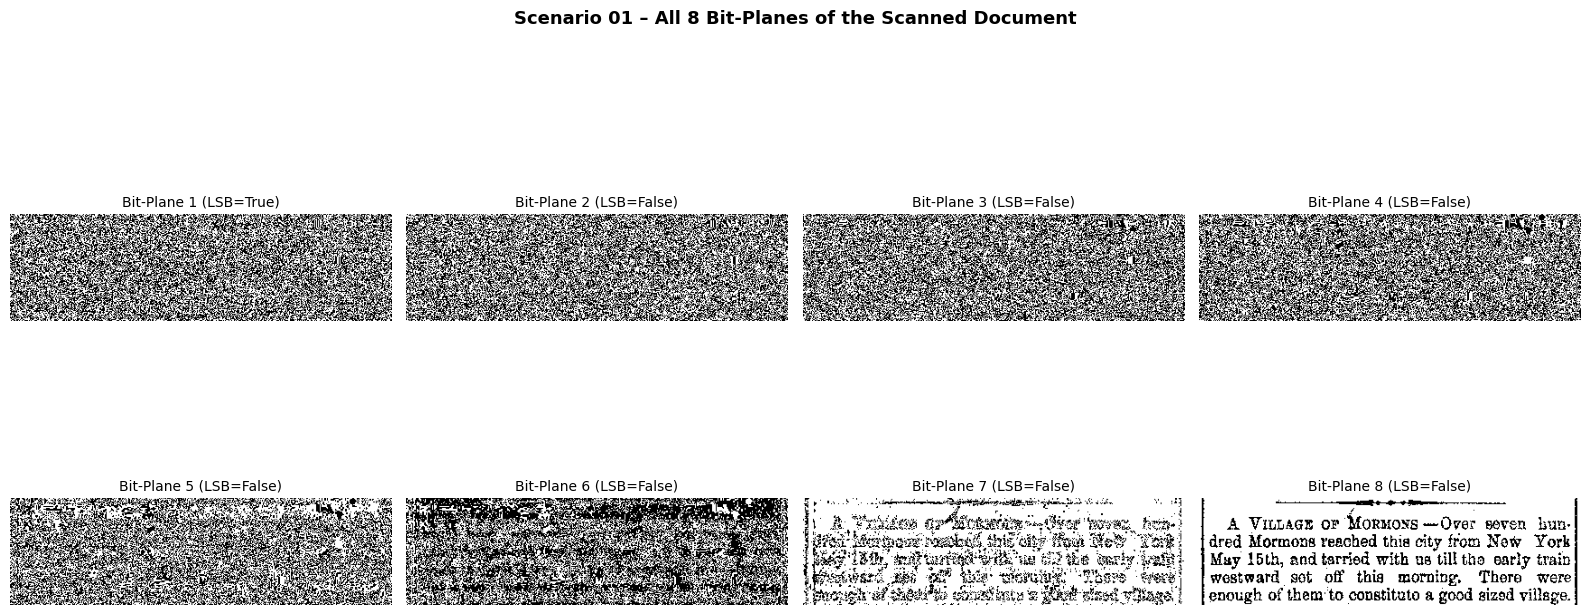

Figure saved as s1_all_bitplanes.png


In [3]:
# ─── TASK 2: Extract & Visualize All 8 Bit-Planes ────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

bit_planes = []
for bit in range(8):
    plane = ((doc_img >> bit) & 1) * 255  # Extract bit and scale to 0 or 255
    bit_planes.append(plane.astype(np.uint8))
    axes[bit].imshow(plane, cmap='gray')
    axes[bit].set_title(f'Bit-Plane {bit + 1} (LSB={bit==0})', fontsize=10)
    axes[bit].axis('off')

plt.suptitle('Scenario 01 – All 8 Bit-Planes of the Scanned Document', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s1_all_bitplanes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s1_all_bitplanes.png')

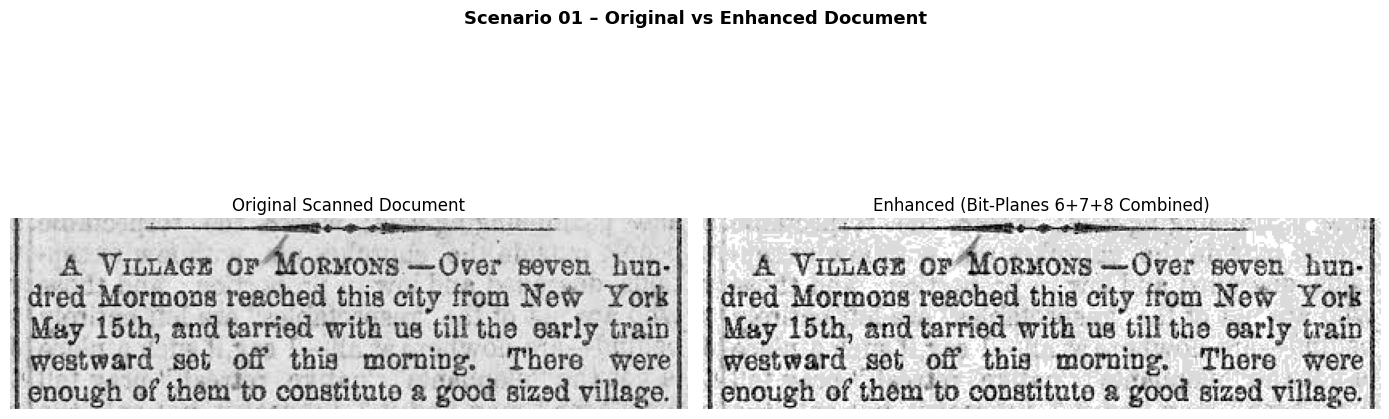

Figure saved as s1_comparison.png


In [4]:
# ─── TASK 3 & 4: Combine Higher-Order Bit-Planes (6, 7, 8) & Compare ─────────
# Higher-order bit planes (bits 5,6,7 in 0-indexed) carry the most significant
# intensity information — combining them removes low-bit noise.

# Combine bit-planes 6, 7, 8 (index 5, 6, 7)
enhanced_doc = (bit_planes[5] & (1 << 5)) | \
               (bit_planes[6] & (1 << 6)) | \
               (bit_planes[7] & (1 << 7))

# Normalize for display
enhanced_doc = cv2.normalize(enhanced_doc.astype(np.float32), None, 0, 255,
                             cv2.NORM_MINMAX).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(doc_img,      cmap='gray'); axes[0].set_title('Original Scanned Document', fontsize=12); axes[0].axis('off')
axes[1].imshow(enhanced_doc, cmap='gray'); axes[1].set_title('Enhanced (Bit-Planes 6+7+8 Combined)', fontsize=12); axes[1].axis('off')

plt.suptitle('Scenario 01 – Original vs Enhanced Document', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s1_comparison.png')

---
#  Scenario 02: Transformation Functions for Night-Time Image Brightening

**Goal:** Brighten a dark night-time image using logarithmic transformation and gamma correction, then compare both results.

### Tasks:
1. Apply a logarithmic transformation to brighten the image.
2. Apply gamma correction to further enhance the image.
3. Compare the results of both transformations.

In [6]:
# ─── Upload Night-Time Image ──────────────────────────────────────────────────

print('Please upload your NIGHT-TIME IMAGE:')
uploaded2 = files.upload()

night_filename = list(uploaded2.keys())[0]
night_img = cv2.imread(night_filename, cv2.IMREAD_GRAYSCALE)

if night_img is None:
    raise ValueError(f'Could not read image: {night_filename}')

print(f'Image loaded: {night_filename}  |  Shape: {night_img.shape}')

Please upload your NIGHT-TIME IMAGE:


Saving 2.jpg to 2.jpg
Image loaded: 2.jpg  |  Shape: (275, 183)


In [9]:
import numpy as np
import cv2

# Ensure image is in float32 for processing
night_img_float = night_img.astype(np.float32)

# ─── TASK 1: Logarithmic Transformation ──────────────────────────────────────
# Apply log1p and handle potential non-finite values
log_input = np.log1p(night_img_float)
log_input[~np.isfinite(log_input)] = 0  # Safety check: convert inf/nan to 0

# Manual Normalization (Much safer than cv2.normalize)
min_val = log_input.min()
max_val = log_input.max()

if max_val - min_val > 0:
    # Scale to 0-255 using NumPy broadcasting
    log_transformed = (255 * (log_input - min_val) / (max_val - min_val)).astype(np.uint8)
else:
    # Handle the case where the image is flat/solid color
    log_transformed = np.zeros_like(night_img, dtype=np.uint8)

# ─── TASK 2: Gamma Correction ─────────────────────────────────────────────────
gamma = 0.4  # Value < 1 brightens, > 1 darkens

# Ensure normalized range [0, 1] before exponentiation to avoid overflow errors
img_normalized = night_img_float / 255.0
gamma_corrected = (np.power(img_normalized, 1.0 / gamma) * 255).astype(np.uint8)

print(f'Log Transformation applied.')
print(f'Gamma Correction applied (gamma = {gamma}).')

Log Transformation applied.
Gamma Correction applied (gamma = 0.4).


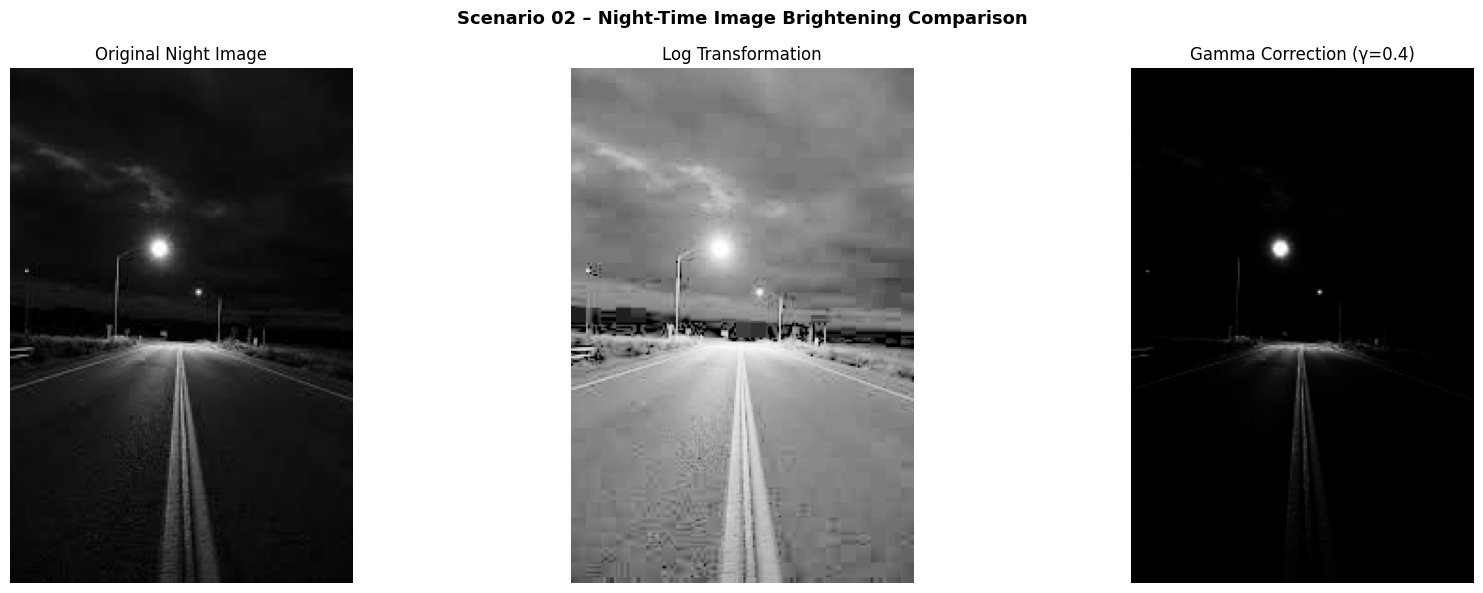

Figure saved as s2_night_comparison.png


In [10]:
# ─── TASK 3: Compare All Three ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(night_img,       cmap='gray'); axes[0].set_title('Original Night Image',          fontsize=12); axes[0].axis('off')
axes[1].imshow(log_transformed, cmap='gray'); axes[1].set_title('Log Transformation',            fontsize=12); axes[1].axis('off')
axes[2].imshow(gamma_corrected, cmap='gray'); axes[2].set_title(f'Gamma Correction (γ={gamma})', fontsize=12); axes[2].axis('off')

plt.suptitle('Scenario 02 – Night-Time Image Brightening Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s2_night_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s2_night_comparison.png')

---
#  Scenario 03: Enhancing Old Manuscripts for Digital Archiving

**Goal:** Restore digitized old manuscripts that have faded ink, uneven lighting, and noise to improve readability for digital archiving.

### Tasks:
1. Use log transformation to enhance faded text.
2. Apply gray-level transformation to balance lighting.
3. Apply contrast stretching to improve readability.
4. Use thresholding to remove the background and extract text.

In [11]:
# ─── Upload Old Manuscript Image ─────────────────────────────────────────────

print('Please upload your OLD MANUSCRIPT image:')
uploaded3 = files.upload()

manu_filename = list(uploaded3.keys())[0]
manu_img = cv2.imread(manu_filename, cv2.IMREAD_GRAYSCALE)

if manu_img is None:
    raise ValueError(f'Could not read image: {manu_filename}')

print(f'Image loaded: {manu_filename}  |  Shape: {manu_img.shape}')

Please upload your OLD MANUSCRIPT image:


Saving 3.jpg to 3.jpg
Image loaded: 3.jpg  |  Shape: (279, 180)


In [13]:
import numpy as np
import cv2

# Ensure input is float32 for mathematical operations
img_float = manu_img.astype(np.float32)

# ─── TASK 1: Log Transformation ──────────────────────────────────────────
# 1. Apply log1p
log_vals = np.log1p(img_float)

# 2. Sanitize: Replace NaN or Inf with 0 to prevent normalization errors
log_vals = np.nan_to_num(log_vals, neginf=0, posinf=0, nan=0)

# 3. Manual Min-Max Normalization (More robust than cv2.normalize)
min_v, max_v = log_vals.min(), log_vals.max()
if max_v > min_v:
    # Scale to 0-255 range
    log_manu = ((log_vals - min_v) / (max_v - min_v) * 255).astype(np.uint8)
else:
    # If image is uniform, return black image
    log_manu = np.zeros_like(img_float, dtype=np.uint8)

# ─── TASK 2: Gray-Level Transformation (CLAHE) ──────────────────────────
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_balanced = clahe.apply(log_manu)

# ─── TASK 3: Contrast Stretching ─────────────────────────────────────────
p2, p98 = np.percentile(gray_balanced, (2, 98))
# Clip and normalize using float precision
contrast_stretched = np.clip((gray_balanced.astype(np.float32) - p2) /
                             (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)

# ─── TASK 4: Thresholding ────────────────────────────────────────────────
_, thresholded = cv2.threshold(contrast_stretched, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print('All 4 processing steps applied successfully.')

All 4 processing steps applied successfully.


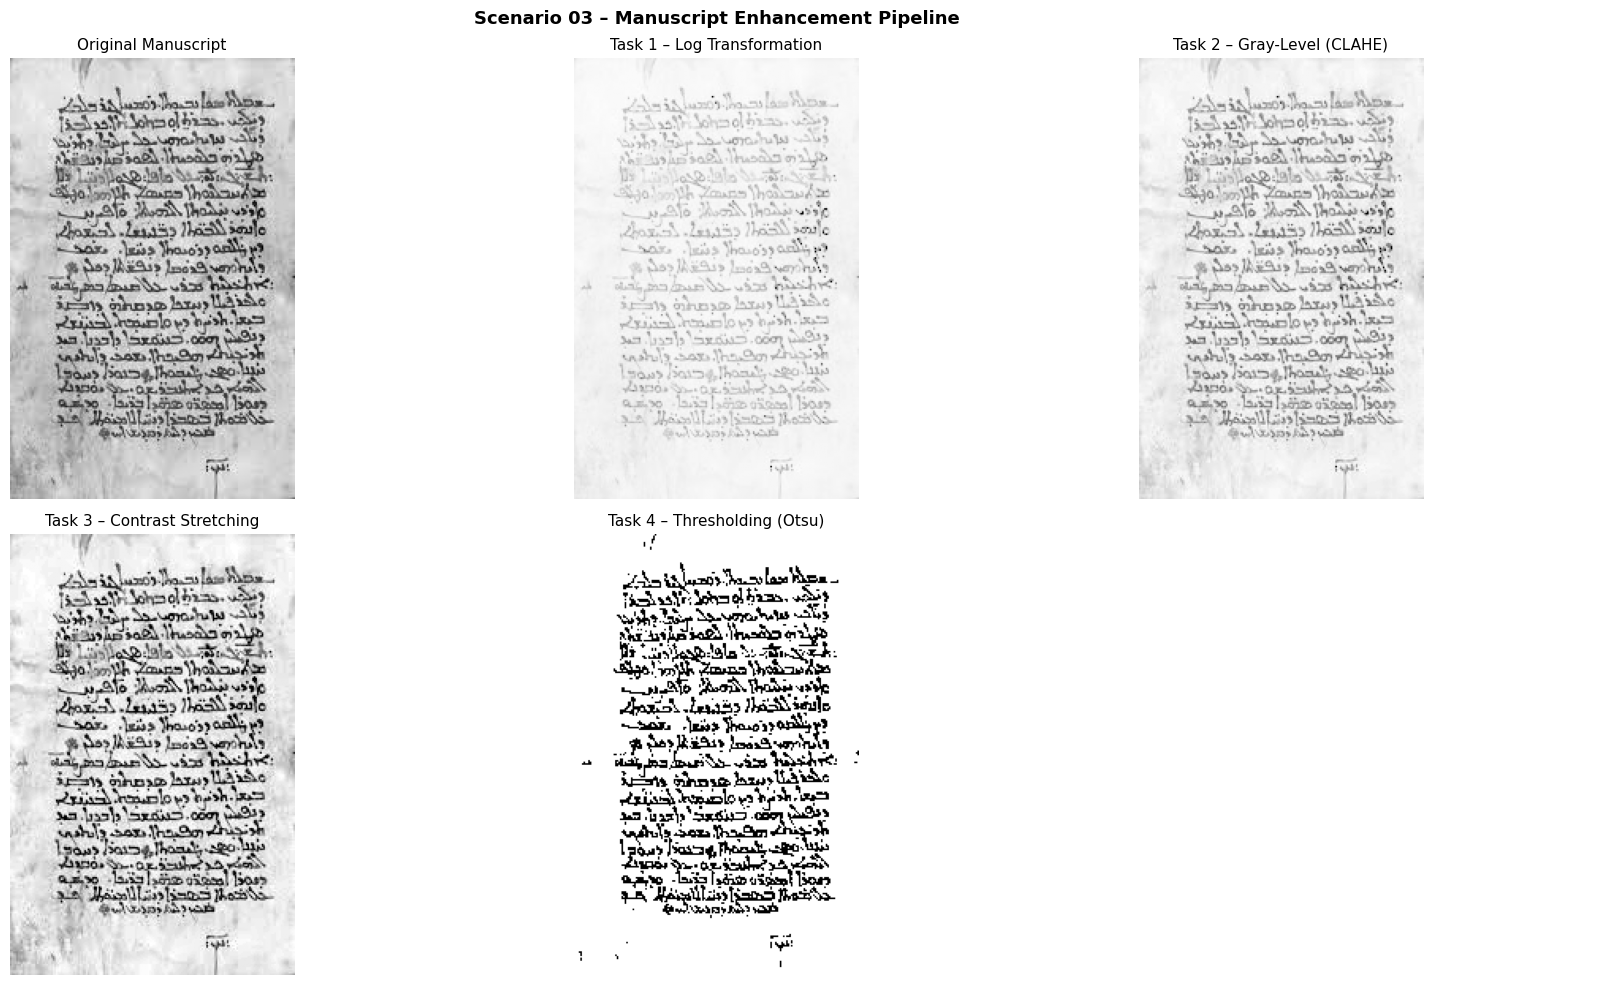

Figure saved as s3_manuscript_pipeline.png


In [14]:
# ─── Visualize All Steps ─────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

images = [manu_img, log_manu, gray_balanced, contrast_stretched, thresholded]
titles = [
    'Original Manuscript',
    'Task 1 – Log Transformation',
    'Task 2 – Gray-Level (CLAHE)',
    'Task 3 – Contrast Stretching',
    'Task 4 – Thresholding (Otsu)'
]

for i, (img, title) in enumerate(zip(images, titles)):
    ax = axes[i // 3][i % 3]
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

axes[1][2].axis('off')  # Hide unused subplot

plt.suptitle('Scenario 03 – Manuscript Enhancement Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s3_manuscript_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s3_manuscript_pipeline.png')

---
#  Scenario 04: License Plate Recognition in Traffic Monitoring

**Goal:** Improve the visibility of license plates from surveillance footage that suffers from varying lighting conditions (too dark or too bright).

### Tasks:
1. Convert image to grayscale.
2. Apply gray-level transformation to improve visibility.
3. Use thresholding to separate text from background.
4. Apply log transformation to enhance low-light images.

In [15]:
# ─── Upload License Plate / Traffic Image ────────────────────────────────────

print('Please upload your LICENSE PLATE / TRAFFIC image:')
uploaded4 = files.upload()

plate_filename = list(uploaded4.keys())[0]
plate_color = cv2.imread(plate_filename)  # Load in color first

if plate_color is None:
    raise ValueError(f'Could not read image: {plate_filename}')

print(f'Image loaded: {plate_filename}  |  Shape: {plate_color.shape}')

Please upload your LICENSE PLATE / TRAFFIC image:


Saving 4.jpg to 4.jpg
Image loaded: 4.jpg  |  Shape: (179, 282, 3)


In [17]:
import numpy as np
import cv2

# ─── TASK 4: Log Transformation (enhance low-light areas) ────────────────────

# 1. Apply log1p and handle potential math errors
log_data = np.log1p(plate_gray.astype(np.float32))
log_data = np.nan_to_num(log_data, neginf=0, posinf=0, nan=0)

# 2. Get min and max to perform manual normalization
min_val = log_data.min()
max_val = log_data.max()

# 3. Safely normalize: check if max > min to avoid division by zero
if max_val > min_val:
    plate_log = ((log_data - min_val) / (max_val - min_val) * 255).astype(np.uint8)
else:
    # Handle edge case: if the image is solid, return a black image
    plate_log = np.zeros_like(plate_gray, dtype=np.uint8)

print('Log transformation applied safely.')

Log transformation applied safely.


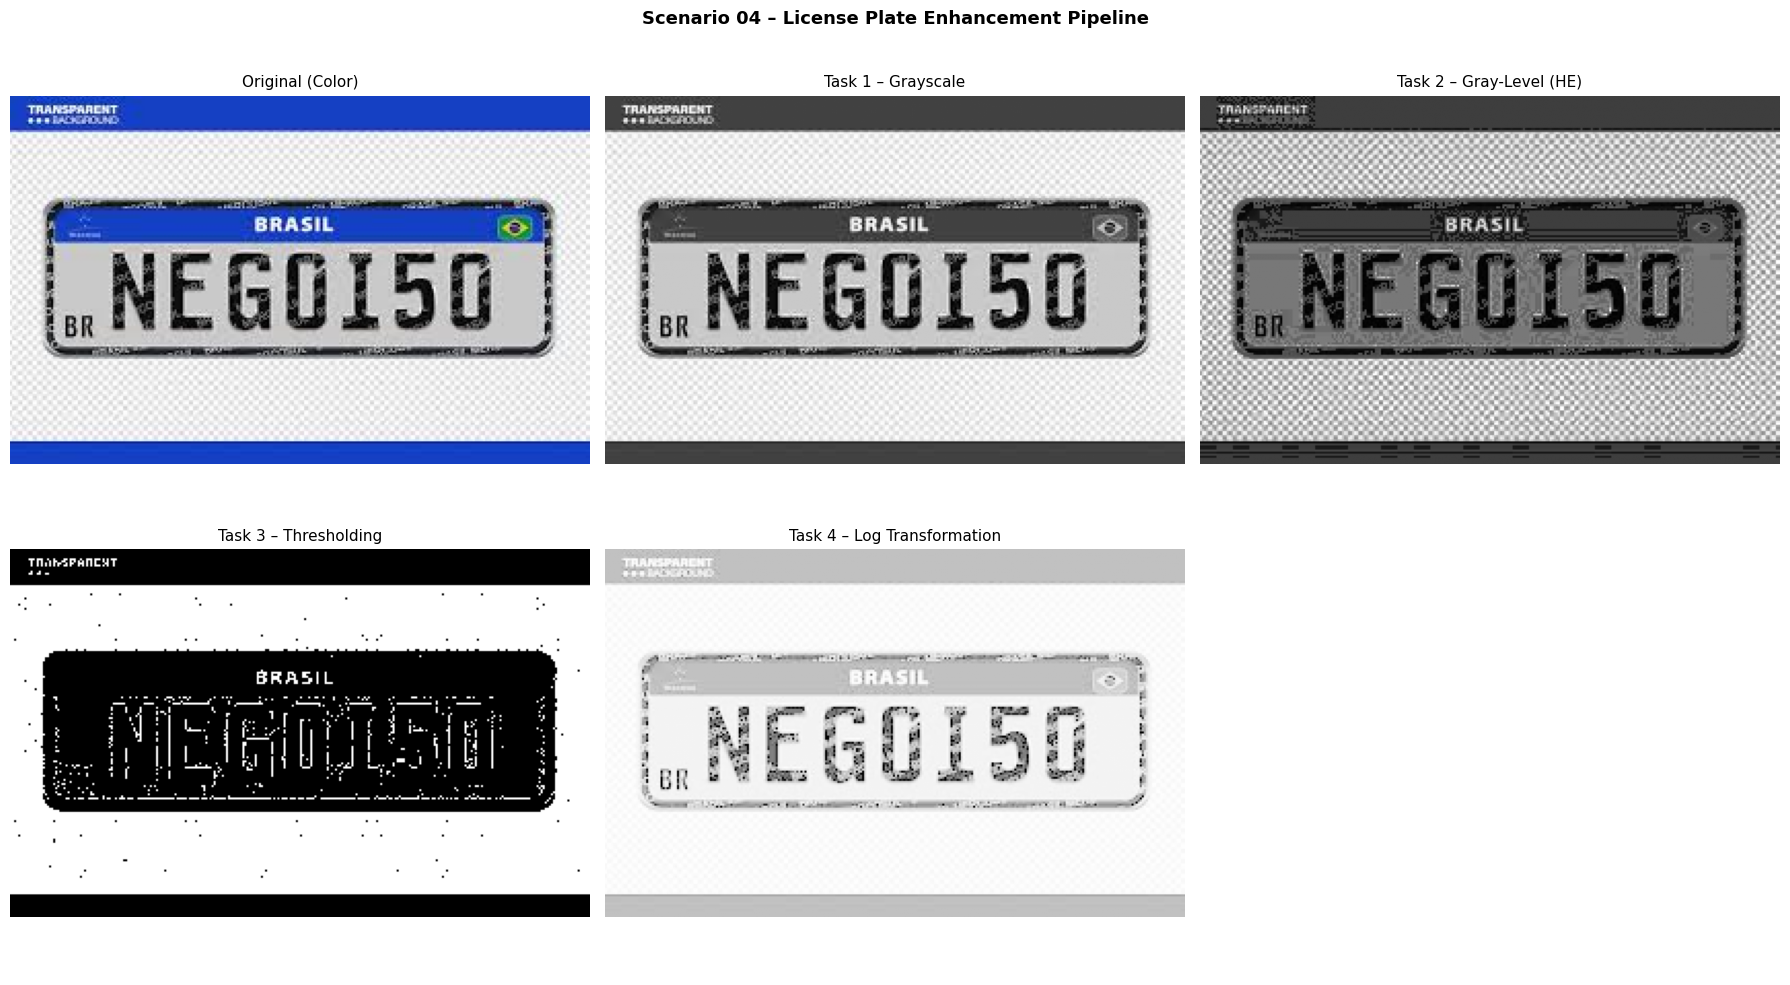

Figure saved as s4_license_plate_pipeline.png


In [18]:
# ─── Visualize All Steps ─────────────────────────────────────────────────────

plate_color_rgb = cv2.cvtColor(plate_color, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

display = [
    (plate_color_rgb, 'Original (Color)',          False),
    (plate_gray,      'Task 1 – Grayscale',        True),
    (plate_equalized, 'Task 2 – Gray-Level (HE)',  True),
    (plate_thresh,    'Task 3 – Thresholding',     True),
    (plate_log,       'Task 4 – Log Transformation', True),
]

for i, (img, title, gray) in enumerate(display):
    ax = axes[i // 3][i % 3]
    ax.imshow(img, cmap='gray' if gray else None)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

axes[1][2].axis('off')  # Hide unused subplot

plt.suptitle('Scenario 04 – License Plate Enhancement Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s4_license_plate_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s4_license_plate_pipeline.png')